# Cosmic Ray Detection in Astronomical Images

## Overview
This notebook demonstrates an astronomical image analysis task using Python and computer vision techniques.

## Objective
- Detect cosmic ray artifacts
- Apply thresholding and contour filtering
- Count detected rays


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
img = cv2.imread("cosmic_rays2.jpg")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
median = cv2.medianBlur(gray, 5)
diff = cv2.absdiff(gray, median)
_, thresh = cv2.threshold(diff, 30, 255, cv2.THRESH_BINARY)

In [3]:
kernel = np.ones((3,3), np.uint8)
thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

In [4]:
count = 0
for c in contours:

    area = cv2.contourArea(c)
    if 3 < area < 200:

        x,y,w,h = cv2.boundingRect(c)
        cv2.rectangle(img,(x,y),(x+w,y+h),(0,255,0),1)
        count += 1

Detected Cosmic Rays: 15


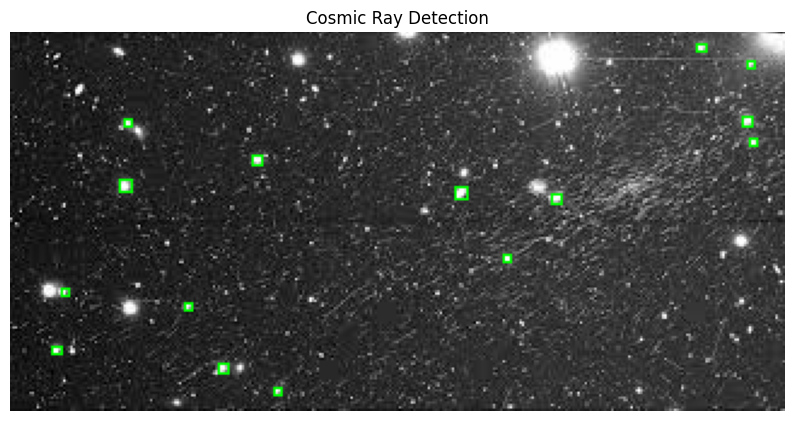

In [5]:
print("Detected Cosmic Rays:", count)
plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Cosmic Ray Detection")
plt.axis("off")
plt.show()

## Conclusion
The analysis successfully demonstrates application of computer vision techniques on astronomical image data.

## Key Techniques Used
- OpenCV
- Thresholding
- Contour Detection
